# **Imports & main parameters**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import *
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
import tensorflow as tf
from tensorflow.keras import Model , layers


from sklearn.model_selection import train_test_split

import os
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 100
SEED = 42

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ashfakyeafi/cat-dog-images-for-classification/cat_dog.csv")
df

,image,labels
0,dog.11289.jpg,1
1,cat.10836.jpg,0
2,cat.7970.jpg,0
3,cat.2212.jpg,0
4,dog.2653.jpg,1
...,...,...
24995,dog.12201.jpg,1
24996,dog.2893.jpg,1
24997,cat.12267.jpg,0
24998,dog.4380.jpg,1


# **Read Dataset and make Datasets**

In [3]:
image_folder = "/kaggle/input/datasets/ashfakyeafi/cat-dog-images-for-classification/cat_dog"

paths = [os.path.join(image_folder, img) for img in df["image"]]
labels = df["labels"].tolist()

train_paths, test_paths, train_labels, test_labels = train_test_split(
    paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths,
    train_labels,
    test_size=0.2,
    random_state=42,
    stratify=train_labels
)

print("Train:", len(train_paths))
print("Validation:", len(val_paths))
print("Test:", len(test_paths))

Train: 16000
Validation: 4000
Test: 5000


In [4]:
def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

def make_dataset(paths, labels, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    ds = ds.map(
        load_and_preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(paths),
            seed=SEED
        )

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

train_ds = make_dataset(train_paths, train_labels, shuffle=True)
val_ds = make_dataset(val_paths, val_labels)
test_ds = make_dataset(test_paths, test_labels)

I0000 00:00:1785026234.674251      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# **Visualization**

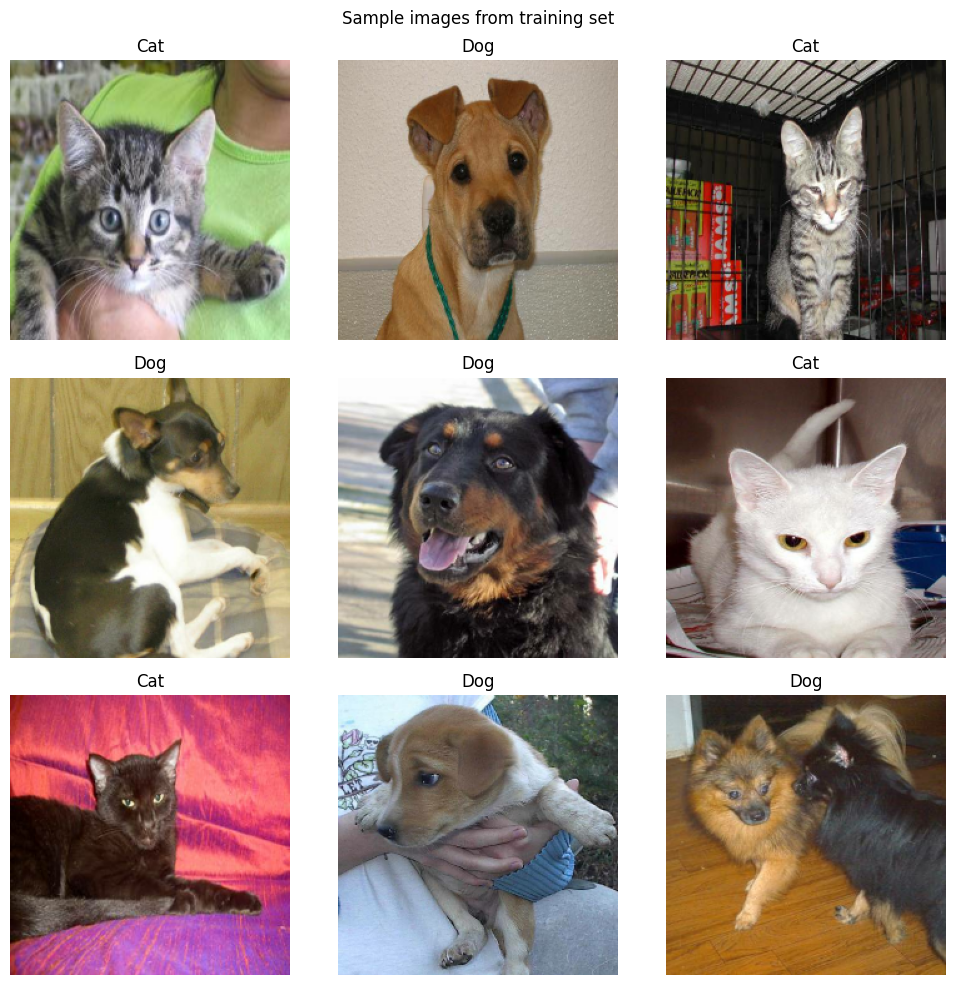

In [5]:
for batch_images, batch_labels in train_ds.take(1):
    images = batch_images
    labels = batch_labels
    break

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    img = images[i]
    img = img / 255.0
    img = images[i].numpy().astype("uint8")
    plt.imshow(img)
    label_idx = labels[i].numpy()
    plt.title("Dog" if labels[i]==1 else "Cat")
    plt.axis("off")

plt.suptitle("Sample images from training set")
plt.tight_layout()
plt.show()

# **Patch Embedding**

In [6]:
def scale_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(scale_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(scale_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = test_ds.map(scale_image, num_parallel_calls=tf.data.AUTOTUNE)



In [7]:
PATCH_SIZE = 16

def extract_patches(images, label):
    patches = tf.image.extract_patches(
        images=images,
        sizes=[1, PATCH_SIZE, PATCH_SIZE, 1],
        strides=[1, PATCH_SIZE, PATCH_SIZE, 1],
        rates=[1, 1, 1, 1],
        padding="VALID"
    )

    # images already has a batch dim (dataset is batched) -> patches: (batch, 14, 14, 768)
    # reshape to (batch, num_patches, patch_dim) = (batch, 196, 768)
    batch_size = tf.shape(images)[0]
    patches = tf.reshape(patches, (batch_size, -1, PATCH_SIZE * PATCH_SIZE * 3))

    return patches, label

train_patch_ds = train_ds.map(extract_patches, num_parallel_calls=tf.data.AUTOTUNE)
val_patch_ds   = val_ds.map(extract_patches, num_parallel_calls=tf.data.AUTOTUNE)
test_patch_ds  = test_ds.map(extract_patches, num_parallel_calls=tf.data.AUTOTUNE)

# Prefetch
train_patch_ds = train_patch_ds.prefetch(tf.data.AUTOTUNE)
val_patch_ds   = val_patch_ds.prefetch(tf.data.AUTOTUNE)
test_patch_ds  = test_patch_ds.prefetch(tf.data.AUTOTUNE)


In [8]:
for patches, labels in train_patch_ds.take(1):
    print("Patches shape:", patches.shape)
    print("Labels shape :", labels.shape)

Patches shape: (32, 196, 768)
Labels shape : (32,)


Patches shape: (32, 196, 768)
Labels shape : (32,)


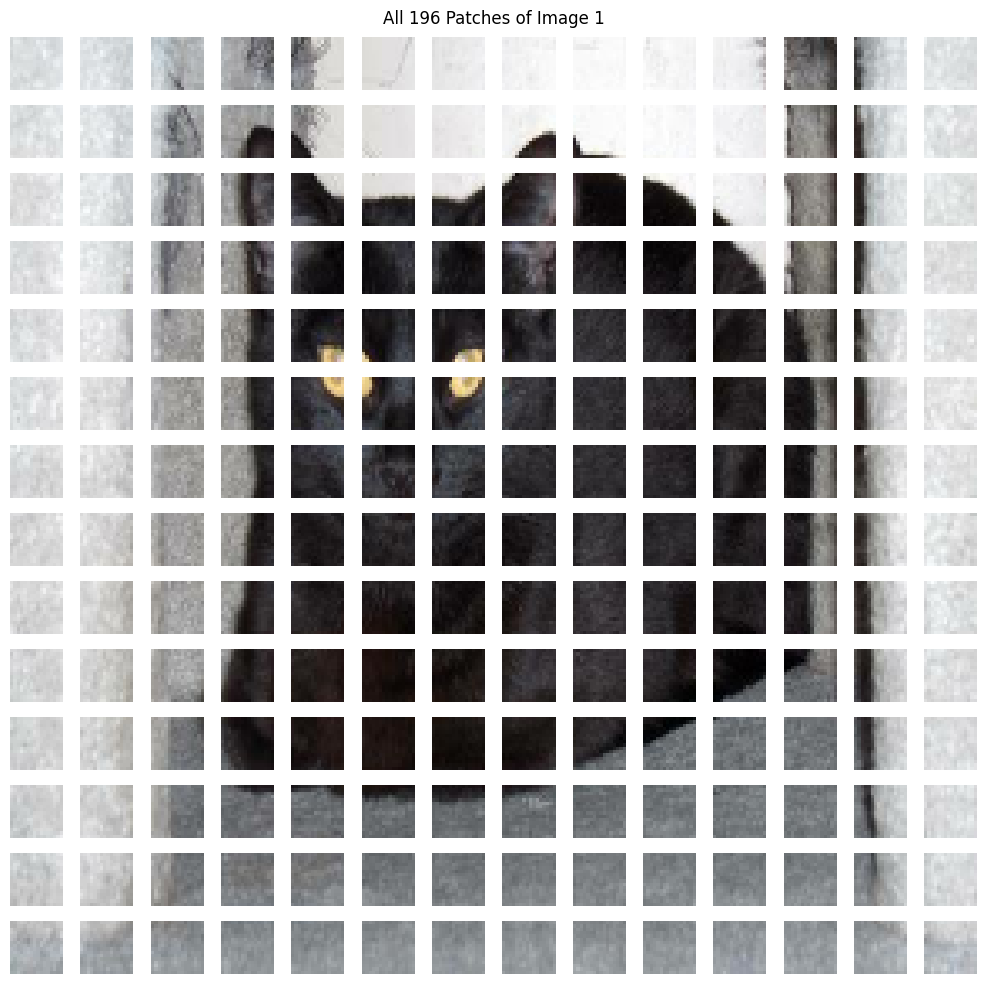

In [9]:
for patches, labels in train_patch_ds.take(1):
    print("Patches shape:", patches.shape)
    print("Labels shape :", labels.shape)

plt.figure(figsize=(10,10))
for i in range(196):
    plt.subplot(14, 14, i+1)
    patch_img = patches[0, i].numpy().reshape(PATCH_SIZE, PATCH_SIZE, 3)
    plt.imshow(patch_img)
    plt.axis("off")

plt.suptitle("All 196 Patches of Image 1")
plt.tight_layout()
plt.show()

# **Adding Position Encoding and Cls Tokens**

In [10]:
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2   # 196
EMBED_DIM   = 128
NUM_HEADS   = 4
NUM_LAYERS  = 4
MLP_DIM     = 256
DROPOUT     = 0.2

position_embedding_layer = Embedding(input_dim=NUM_PATCHES + 1, output_dim=EMBED_DIM)
cls_embedding_layer = Embedding(input_dim=1, output_dim=EMBED_DIM)

def get_cls_index(x):
    batch_size = tf.shape(x)[0]
    return tf.zeros((batch_size, 1), dtype="int32")

def add_positions(x):
    positions = tf.range(start=0, limit=NUM_PATCHES + 1, delta=1)
    return x + position_embedding_layer(positions)

def patch_position_embedding(patches):
    projected = Dense(EMBED_DIM)(patches)                      # (batch, 196, embed_dim)

    cls_idx = Lambda(get_cls_index)(projected)                 # (batch, 1) كلها zeros
    cls_tokens = cls_embedding_layer(cls_idx)                  # (batch, 1, embed_dim)

    x = Concatenate(axis=1)([cls_tokens, projected])           # (batch, 197, embed_dim)
    x = Lambda(add_positions)(x)

    return x

# **Transformer Encoder Block**

In [11]:
L2_REG = 1e-4

def transformer_block(x):
    x1 = LayerNormalization(epsilon=1e-6)(x)
    attn_out = MultiHeadAttention(
        num_heads=NUM_HEADS,
        key_dim=EMBED_DIM // NUM_HEADS,
        dropout=DROPOUT,
        kernel_regularizer=l2(L2_REG)
    )(x1, x1)
    x = x + attn_out

    x2 = LayerNormalization(epsilon=1e-6)(x)
    mlp_out = Dense(MLP_DIM, activation="relu", kernel_regularizer=l2(L2_REG))(x2)
    mlp_out = Dropout(DROPOUT)(mlp_out)
    mlp_out = Dense(EMBED_DIM, kernel_regularizer=l2(L2_REG))(mlp_out)
    mlp_out = Dropout(DROPOUT)(mlp_out)
    x = x + mlp_out

    return x

# **Build Model**

In [12]:
def build_vit():
    inputs = Input(shape=(NUM_PATCHES, PATCH_SIZE * PATCH_SIZE * 3))
    x = patch_position_embedding(inputs)

    for _ in range(NUM_LAYERS):
        x = transformer_block(x)

    x = LayerNormalization(epsilon=1e-6)(x)
    cls_output = x[:, 0]

    x = Dense(MLP_DIM, activation="gelu")(cls_output)
    x = Dropout(DROPOUT)(x)
    outputs = Dense(1, activation="sigmoid")(x)

    return Model(inputs, outputs, name="vit_baseline")

vit_model = build_vit()
vit_model.summary()

Model: "vit_baseline"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 196, 768)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 196, 128)  │     98,432 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 128)    │        128 │ lambda[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 197, 128)  │          0 │ embedding_1[0][0… │
│ (Concatenate)       │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 197, 128)  │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 197, 128)  │        256 │ lambda_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 197, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 197, 128)  │          0 │ lambda_1[0][0],   │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 197, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 197, 256)  │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 197, 256)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 197, 128)  │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 197, 128)  │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 197, 128)  │          0 │ add[0][0],        │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 197, 128)  │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 197, 128)  │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 197, 128)  │          0 │ add_1[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 197, 128)  │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 662,017 (2.53 MB)

 Trainable params: 662,017 (2.53 MB)

 Non-trainable params: 0 (0.00 B)

# **Compile & callbacks**

In [13]:
vit_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


callbacks = [
    
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    
    ModelCheckpoint(
        '/kaggle/working/best_vit.weights.h5',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# **Training**

In [14]:
history = vit_model.fit(
    train_patch_ds,
    validation_data=val_patch_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
  5/500 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.5272 - loss: 0.9450

I0000 00:00:1785026336.230883      66 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5195 - loss: 0.8559
Epoch 1: val_loss improved from None to 0.77418, saving model to /kaggle/working/best_vit.weights.h5



Epoch 1: finished saving model to /kaggle/working/best_vit.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 48ms/step - accuracy: 0.5175 - loss: 0.8244 - val_accuracy: 0.5370 - val_loss: 0.7742 - learning_rate: 0.0010
Epoch 2/100
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5474 - loss: 0.7636
Epoch 2: val_loss improved from 0.77418 to 0.74371, saving model to /kaggle/working/best_vit.weights.h5



Epoch 2: finished saving model to /kaggle/working/best_vit.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 34ms/step - accuracy: 0.5468 - loss: 0.7528 - val_accuracy: 0.5100 - val_loss: 0.7437 - learning_rate: 0.0010
Epoch 3/100
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5567 - loss: 0.7237
Epoch 3: val_loss improved from 0.74371 to 0.70948, saving model to /kaggle/working/best_vit.weights.h5


...


Epoch 19: finished saving model to /kaggle/working/best_vit.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.7071 - loss: 0.5779 - val_accuracy: 0.7082 - val_loss: 0.5746 - learning_rate: 0.0010
Epoch 20/100
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7148 - loss: 0.5705
Epoch 20: val_loss did not improve from 0.57459
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.7131 - loss: 0.5716 - val_accuracy: 0.6827 - val_loss: 0.6097 - learning_rate: 0.0010
Epoch 21/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7177 - loss: 0.5728
Epoch 21: val_loss did not improve from 0.57459
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 35ms/step - accuracy: 0.7151 - loss: 0.5722 - val_accuracy: 0.7072 - val_loss: 0.5851 - learning_rate: 0.0010
Epoch 22/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7137 - loss: 0.5704
Epoch 22: val_loss did not improve from 0.57459
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.7147 - loss: 0.5671 - val_accur


Epoch 24: finished saving model to /kaggle/working/best_vit.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.7376 - loss: 0.5394 - val_accuracy: 0.7122 - val_loss: 0.5691 - learning_rate: 4.0000e-04
Epoch 25/100
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7426 - loss: 0.5264
Epoch 25: val_loss did not improve from 0.56911
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.7376 - loss: 0.5331 - val_accuracy: 0.7175 - val_loss: 0.5776 - learning_rate: 4.0000e-04
Epoch 26/100
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7528 - loss: 0.5199
Epoch 26: val_loss did not improve from 0.56911
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.7452 - loss: 0.5305 - val_accuracy: 0.7200 - val_loss: 0.5736 - learning_rate: 4.0000e-04
Epoch 27/100
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7439 - loss: 0.5300
Epoch 27: val_loss improved from 0.56911 to 0.56773, saving model to /kaggle/working/best_vit.weights.h5



Epoch 27: finished saving model to /kaggle/working/best_vit.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.7488 - loss: 0.5270 - val_accuracy: 0.7163 - val_loss: 0.5677 - learning_rate: 4.0000e-04
Epoch 28/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7536 - loss: 0.5207
Epoch 28: val_loss improved from 0.56773 to 0.56242, saving model to /kaggle/working/best_vit.weights.h5



Epoch 28: finished saving model to /kaggle/working/best_vit.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.7499 - loss: 0.5232 - val_accuracy: 0.7212 - val_loss: 0.5624 - learning_rate: 4.0000e-04
Epoch 29/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7509 - loss: 0.5236
Epoch 29: val_loss did not improve from 0.56242
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.7553 - loss: 0.5185 - val_accuracy: 0.7130 - val_loss: 0.5672 - learning_rate: 4.0000e-04
Epoch 30/100
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7633 - loss: 0.5077
Epoch 30: val_loss did not improve from 0.56242
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 32ms/step - accuracy: 0.7563 - loss: 0.5165 - val_accuracy: 0.7195 - val_loss: 0.5647 - learning_rate: 4.0000e-04
Epoch 31/100
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7682 - loss: 0.5065
Epoch 31: val_loss did not improve from 0.56242
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.7632 - loss: 0.5112


Epoch 32: finished saving model to /kaggle/working/best_vit.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.7623 - loss: 0.5085 - val_accuracy: 0.7195 - val_loss: 0.5554 - learning_rate: 4.0000e-04
Epoch 33/100
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7654 - loss: 0.5033
Epoch 33: val_loss did not improve from 0.55537
500/500 ━━━━━━━━━━━━━━━━━━━━ 30s 35ms/step - accuracy: 0.7630 - loss: 0.5056 - val_accuracy: 0.7200 - val_loss: 0.5857 - learning_rate: 4.0000e-04
Epoch 34/100
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7651 - loss: 0.5020
Epoch 34: val_loss did not improve from 0.55537
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.7636 - loss: 0.5056 - val_accuracy: 0.7190 - val_loss: 0.5687 - learning_rate: 4.0000e-04
Epoch 35/100
499/500 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7744 - loss: 0.4922
Epoch 35: val_loss did not improve from 0.55537
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.7691 - loss: 0.4971

# **Loss & Accuracy Plot**

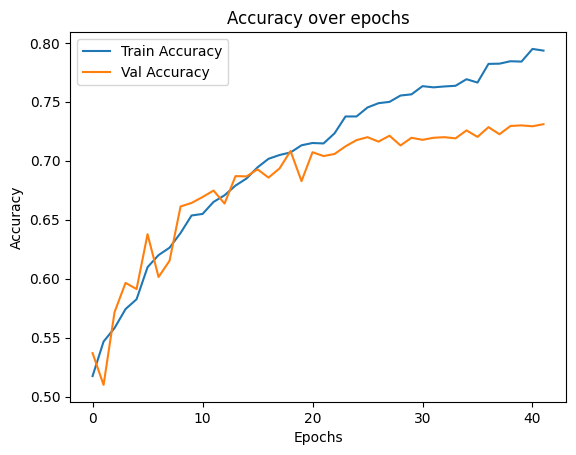

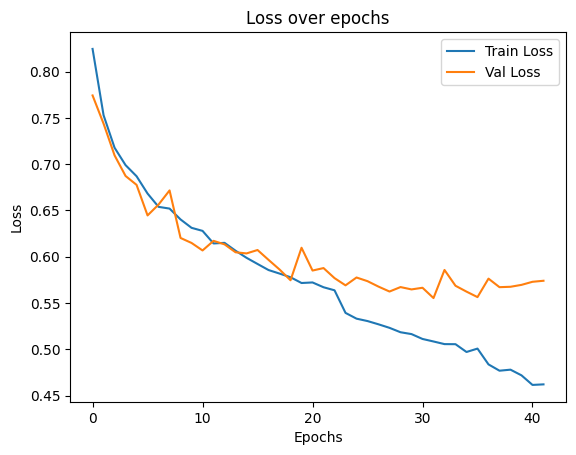

In [15]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')



plt.legend()
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()


# -- Plot training vs validation loss --
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')

plt.legend()
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step


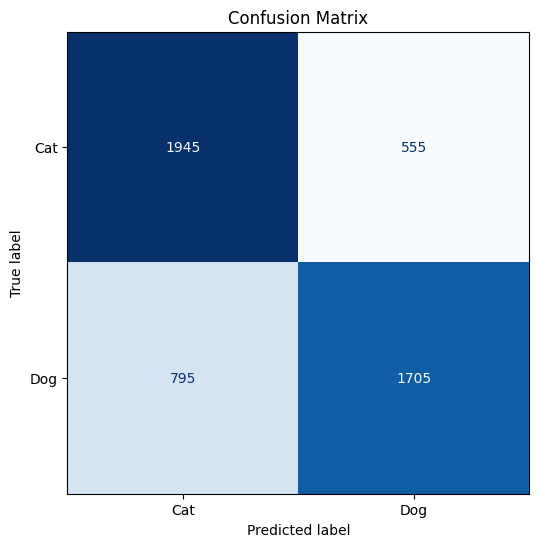

Classification Report

              precision    recall  f1-score   support

         Cat       0.71      0.78      0.74      2500
         Dog       0.75      0.68      0.72      2500

    accuracy                           0.73      5000
   macro avg       0.73      0.73      0.73      5000
weighted avg       0.73      0.73      0.73      5000



In [16]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# لازم test_patch_ds مش test_ds، لأن الموديل مدرب على الـ patches
y_pred = vit_model.predict(test_patch_ds)
predicted_labels = (y_pred >= 0.5).astype(int).flatten()

true_labels = []
for patches, labels in test_patch_ds:
    true_labels.extend(labels.numpy())
true_labels = np.array(true_labels)

# ============================
# Confusion Matrix
# ============================
cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

# ============================
# Classification Report
# ============================
print("Classification Report\n")
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=["Cat", "Dog"]
    )
)